In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("startup_funding.csv")
df.head()

,SNo,Date,StartupName,IndustryVertical,SubVertical,CityLocation,InvestorsName,InvestmentType,AmountInUSD,Remarks
0,0,01/08/2017,TouchKin,Technology,Predictive Care Platform,Bangalore,Kae Capital,Private Equity,"1,300,000",NaN
1,1,02/08/2017,Ethinos,Technology,Digital Marketing Agency,Mumbai,Triton Investment Advisors,Private Equity,NaN,NaN
2,2,02/08/2017,Leverage Edu,Consumer Internet,Online platform for Higher Education Services,New Delhi,"Kashyap Deorah, Anand Sankeshwar, Deepak Jain,...",Seed Funding,NaN,NaN
3,3,02/08/2017,Zepo,Consumer Internet,DIY Ecommerce platform,Mumbai,"Kunal Shah, LetsVenture, Anupam Mittal, Hetal ...",Seed Funding,"500,000",NaN
4,4,02/08/2017,Click2Clinic,Consumer Internet,healthcare service aggregator,Hyderabad,"Narottam Thudi, Shireesh Palle",Seed Funding,"850,000",NaN


In [8]:
print(df.shape)
print(df.columns)
df.info()
df.isnull().sum()

(2372, 10)
Index(['SNo', 'Date', 'StartupName', 'IndustryVertical', 'SubVertical',
       'CityLocation', 'InvestorsName', 'InvestmentType', 'AmountInUSD',
       'Remarks'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372 entries, 0 to 2371
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   SNo               2372 non-null   int64 
 1   Date              2372 non-null   object
 2   StartupName       2372 non-null   object
 3   IndustryVertical  2201 non-null   object
 4   SubVertical       1436 non-null   object
 5   CityLocation      2193 non-null   object
 6   InvestorsName     2364 non-null   object
 7   InvestmentType    2371 non-null   object
 8   AmountInUSD       1525 non-null   object
 9   Remarks           419 non-null    object
dtypes: int64(1), object(9)
memory usage: 185.4+ KB


SNo                    0
Date                   0
StartupName            0
IndustryVertical     171
SubVertical          936
CityLocation         179
InvestorsName          8
InvestmentType         1
AmountInUSD          847
Remarks             1953
dtype: int64

In [9]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df['Year'] = df['Date'].dt.year

In [10]:
df['AmountInUSD'] = df['AmountInUSD'].astype(str).str.replace(',', '')
df['AmountInUSD'] = pd.to_numeric(df['AmountInUSD'], errors='coerce')
df = df.dropna(subset=['AmountInUSD'])

In [11]:
df['CityLocation'] = df['CityLocation'].str.split('/').str[0].str.strip()
df['CityLocation'] = df['CityLocation'].replace({
    'Delhi': 'New Delhi',
    'bangalore': 'Bangalore'
})

In [12]:
df['InvestorsName'] = df['InvestorsName'].astype(str).str.split(',').str[0]

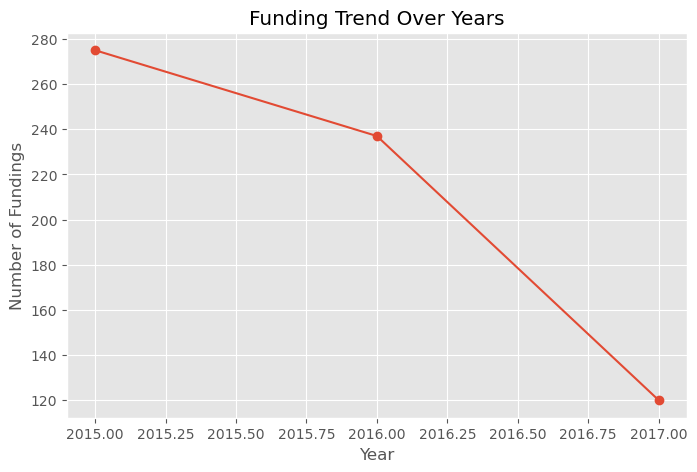

Year
2015    275
2016    237
2017    120
Name: count, dtype: int64

In [13]:
funding_trend = df['Year'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(funding_trend.index, funding_trend.values, marker='o')
plt.title("Funding Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Fundings")
plt.grid(True)
plt.show()

funding_trend

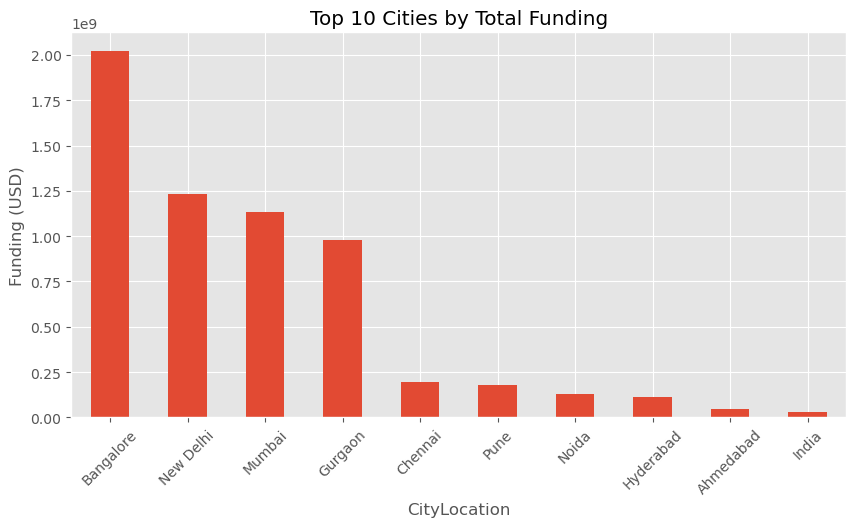

CityLocation
Bangalore    2.023626e+09
New Delhi    1.232058e+09
Mumbai       1.133596e+09
Gurgaon      9.765775e+08
Chennai      1.962220e+08
Pune         1.810170e+08
Noida        1.263200e+08
Hyderabad    1.135300e+08
Ahmedabad    4.595000e+07
India        3.000000e+07
Name: AmountInUSD, dtype: float64

In [14]:
top_cities = (
    df.groupby('CityLocation')['AmountInUSD']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Total Funding")
plt.ylabel("Funding (USD)")
plt.xticks(rotation=45)
plt.show()

top_cities

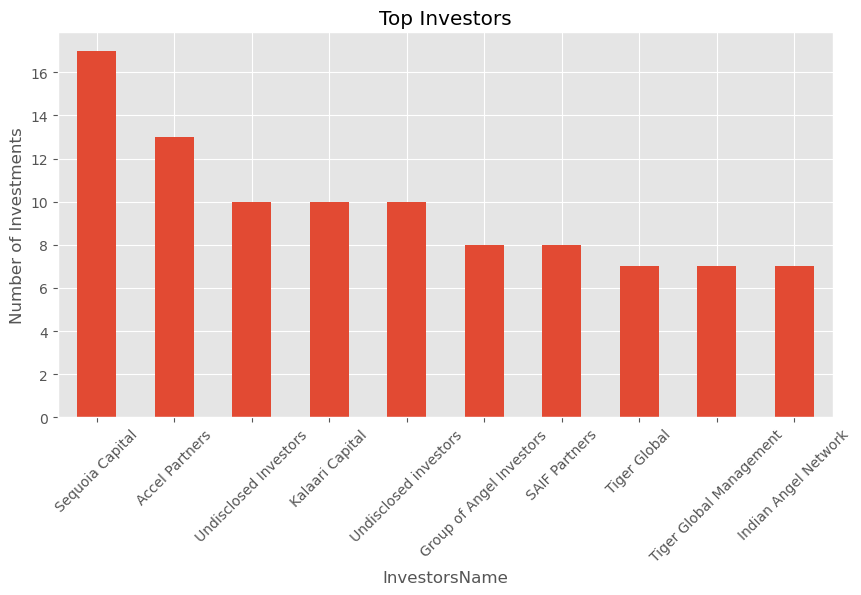

InvestorsName
Sequoia Capital             17
Accel Partners              13
Undisclosed Investors       10
Kalaari Capital             10
Undisclosed investors       10
Group of Angel Investors     8
SAIF Partners                8
Tiger Global                 7
Tiger Global Management      7
Indian Angel Network         7
Name: count, dtype: int64

In [15]:
top_investors = df['InvestorsName'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_investors.plot(kind='bar')
plt.title("Top Investors")
plt.ylabel("Number of Investments")
plt.xticks(rotation=45)
plt.show()

top_investors

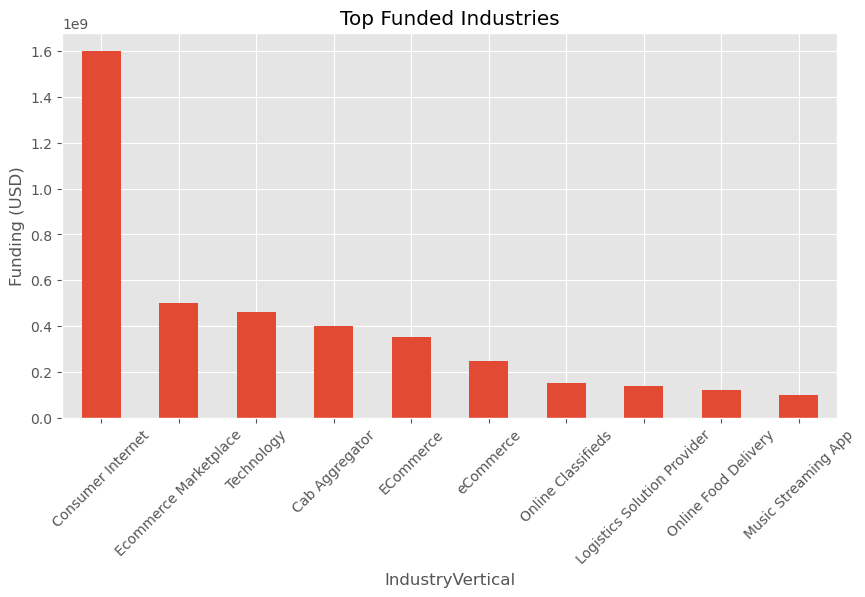

IndustryVertical
Consumer Internet              1.600819e+09
Ecommerce Marketplace          5.000000e+08
Technology                     4.593630e+08
Cab Aggregator                 4.000000e+08
ECommerce                      3.515300e+08
eCommerce                      2.488700e+08
Online Classifieds             1.500000e+08
Logistics Solution Provider    1.370000e+08
Online Food Delivery           1.215000e+08
Music Streaming App            1.000000e+08
Name: AmountInUSD, dtype: float64

In [16]:
top_sectors = (
    df.groupby('IndustryVertical')['AmountInUSD']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_sectors.plot(kind='bar')
plt.title("Top Funded Industries")
plt.ylabel("Funding (USD)")
plt.xticks(rotation=45)
plt.show()

top_sectors

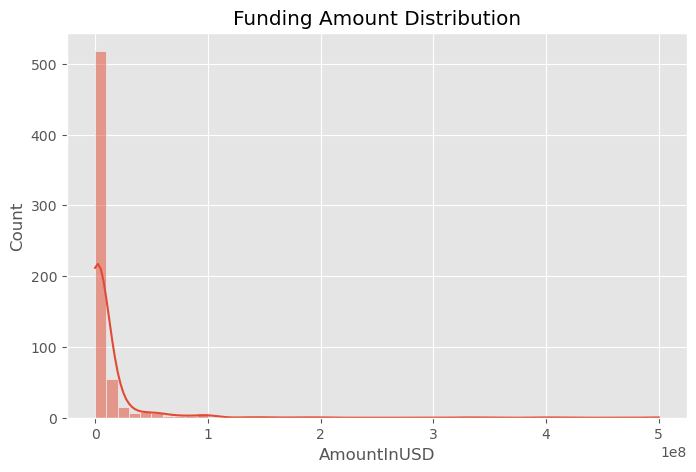

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['AmountInUSD'], bins=50, kde=True)
plt.title("Funding Amount Distribution")
plt.show()

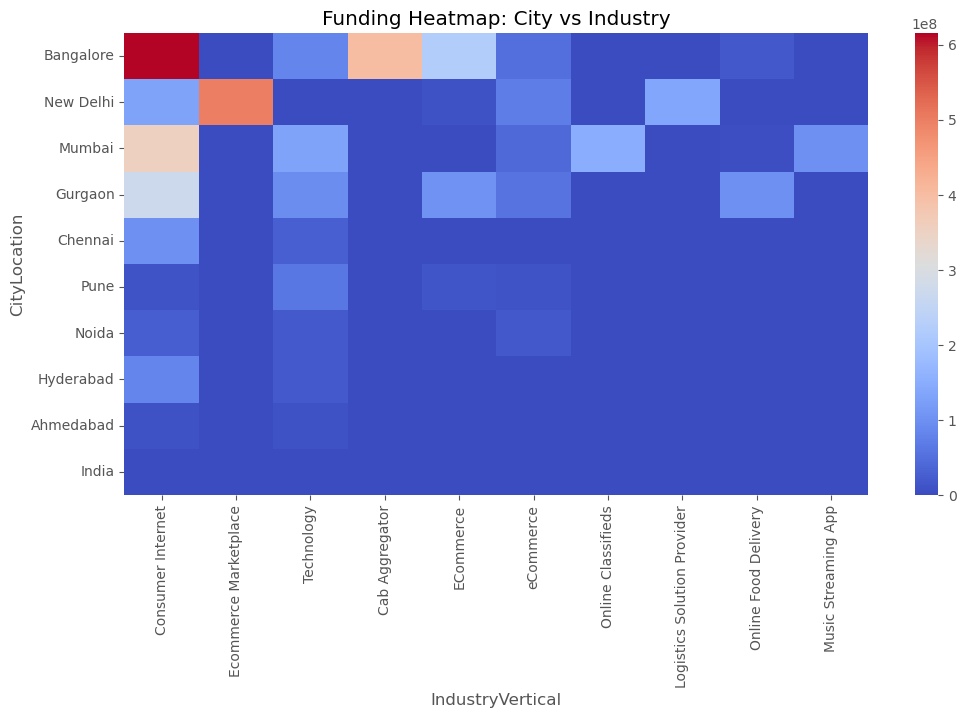

In [18]:
pivot_table = pd.pivot_table(
    df,
    values='AmountInUSD',
    index='CityLocation',
    columns='IndustryVertical',
    aggfunc='sum'
).fillna(0)

top_city_industry = pivot_table.loc[top_cities.index, top_sectors.index]

plt.figure(figsize=(12,6))
sns.heatmap(top_city_industry, cmap="coolwarm")
plt.title("Funding Heatmap: City vs Industry")
plt.show()

In [19]:
plt.savefig("output.png")

<Figure size 640x480 with 0 Axes>